In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

from sca_module.readers import create_dataset
from sca_module.simulate_L2 import GMF_SWB
from sca_module.dopsca_setup import DopSCAConfig
from sca_module.simulate_L1 import compute_beam_pattern, compute_cube_observation_geometry, compute_true_observations, create_observation_cube, compute_lpf_cube, add_L1_uncertainties
from leakage.uncertainties import band_limited_noise
from leakage.conversions import dop2vel, angular_difference, dir_from_u_v, magnitude_from_u_v, convert_to_0_360

func_rmse = lambda x, rounding=3:  np.round(np.sqrt(np.nanmean(x**2)), rounding)

plt.rcParams.update({'font.size': 10, 'font.weight' : 'bold'})

# Data preparation

## 0 - Parameters

In [2]:
sca = DopSCAConfig()
sca.Lambda = sca.get_wavelength()

# The magic_divider is an unnecessary, but convenient, method to resample the input data to some common sampling. 
# The data is loaded with a grid spacing of 1000 m , and the stride during pulses is 1700 m
# Thus, a divider of 2 will interpolate the data to 850 m grid cells
# This prevents aliasing in azimuth, and does not remove range resolution
sca.grid_spacing_target = sca.get_grid_spacing_target(magic_divider=2)
sca.random_state= 2

## 1 - Load data

In [3]:
files_cali = [
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_input_California.nc',
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_output_California.nc'
]

simulation = xr.open_mfdataset(files_cali, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').compute()
sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

# clipping unreasonable incidence angles
simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))
simulation = simulation.assign_coords(grg = simulation.grg + sca.magic_offset)

In [4]:
# Here we interpolate to finer grid spacing, 
new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
simulation = simulation.interp(az=new_az, grg=new_grg)

## 2 - Add necessary fields

In [5]:
nrcs = simulation[sca.var_nrcs].sel(pol='M')
dop = simulation[sca.var_dop].sel(pol='M')
inc_2d = np.degrees(simulation[sca.var_inc].expand_dims(dim={sca.dim_az: simulation.az.data}))

data = create_dataset(
    nrcs=nrcs.data,
    dop=dop.data,
    inc=inc_2d.data,
    grg=simulation.grg.data,
    az=simulation.az.data,
    grid_spacing=sca.grid_spacing_target,
)

## 3 - Convert to 3D observation cube

In [6]:
data_cube = create_observation_cube(data, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF).compute()
data_cube = compute_cube_observation_geometry(data_cube, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

## 4 - Add hypothetical beam pattern

In [7]:
beam = compute_beam_pattern(
    az_angle_wrt_boresight=data_cube.az_angle_wrt_boresight,
    grg_angle_wrt_boresight=data_cube.grg_angle_wrt_boresight,
    antenna_elements=sca.antenna_elements,
    antenna_weighting=sca.antenna_weighting,
    antenna_length=sca.antenna_length,
    antenna_height=sca.antenna_height,
    f0=sca.f0,
    beam_pattern=sca.beam_pattern,
)

data_cube['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

## 5 - Estimate idealized scaterometer observations

In [8]:
data_cube = compute_true_observations(data_cube, sca.var_nrcs, sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

# L1 uncertainty

## 6 - Add uncertainties with SCR computed from the NRCS field

In [13]:
ds = add_L1_uncertainties(
    ds = data_cube,
    dim_range = sca.dim_range,
    dim_az_beam = sca.dim_az_beam,
    vx_sat = sca.vx_sat,
    U = sca.U,
    sat_height = sca.z0,
    T_pp= sca.T_pp,
    Lambda = sca.Lambda,
    fixed_SCR=None, # < -------- here we let the SCR be calculated from the NRCS data 
    grid_spacing_slant_range=sca.grid_spacing_slant_range_SCA,
    random_state=sca.random_state
)

# -- Resample to uniform ground-range spacing
ds = ds.interp(
        grg=np.arange(
            simulation.grg.min(), 
            simulation.grg.max(), 
            sca.grid_spacing_slant_range_SCA
        ) , 
        method=sca.interpolator
    ).astype("float32")
ds = ds.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

## 7 - Correct for the incurred leakage residual

### 7.1 - Remove the NaN edges, which can mess up successive computations

In [15]:
data['nrcs_scat_speckle'] = ([*data['nrcs'].dims], ds['nrcs_scat_speckle'].interp({"az_slow_time":data.az.data, "grg":data.grg.data}).data)
mask = data["nrcs_scat_speckle"].notnull()
data_clean = data.where(mask, drop=True)

### 7.2 - Repeat the leakage estimation, but now using a realization of SCA's estimated NRCS

In [16]:
data_cube_ = create_observation_cube(data_clean, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF, dropna=False).compute()
data_cube_ = compute_cube_observation_geometry(data_cube_, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

beam = compute_beam_pattern(
    az_angle_wrt_boresight=data_cube_.az_angle_wrt_boresight,
    grg_angle_wrt_boresight=data_cube_.grg_angle_wrt_boresight,
    antenna_elements=sca.antenna_elements,
    antenna_weighting=sca.antenna_weighting,
    antenna_length=sca.antenna_length,
    antenna_height=sca.antenna_height,
    f0=sca.f0,
    beam_pattern=sca.beam_pattern,
)

data_cube_['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

# here we use 'nrcs_scat_speckle' as the input NRCS, rather than the noise-free version
data_cube_ = compute_true_observations(data_cube_, 'nrcs_scat_speckle', sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

ds_ = data_cube_

ds_ = ds_.interp(grg=np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_slant_range_SCA), method=sca.interpolator).astype("float32")
ds_ = ds_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

### 7.3 - Calculate the net leakage (incurred - estimated), drop NaN edges

In [18]:
mask_2 = ds_["V_leakage_pulse_rg"].notnull()
ds_filt = ds_.where(mask_2, drop=True)

ds['V_leakage_pulse_rg_net'] = - ds_filt['V_leakage_pulse_rg'] + ds['V_leakage_pulse_rg']
ds['V_sigma_net'] = ds['V_leakage_pulse_rg_net'] + ds['V_pp']

### 7.4 - Low-pass filter to obtain L1 uncertainty at product resolution

In [20]:
assert len(set(np.diff(ds_.grg))) == 1, "ground range sampling is not continuous"

ds = compute_lpf_cube(
        ds,
        resolution_product= sca.resolution_product,
        fs_x=1 / ds.attrs["stride"],
        fs_y=1/np.diff(ds_.grg)[0],
        data_2_lpf=["V_leakage_pulse_rg_net", "V_leakage_pulse_rg", "V_sigma_net", "V_sigma", "V_pp"],
        window=sca.product_averaging_window,
        crop_edges = True
    )

In [14]:
# quick assessment if the magnitudes make sense
func_rmse(ds['V_pp_lpf']), func_rmse(ds['V_sigma_net_lpf']), func_rmse(ds['V_sigma_lpf'])

(1.753, 1.849, 2.191)

# L2 uncertainty

## 8 - Open Look Up Tables (for wave-Doppler estimation)

In [22]:
lut_dop = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/dop_lut_20250213_companion350km.nc')['dop_S1_V']
lut_nrcs = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/nrcs_lut_20250213_companion350km.nc')['nrcs_S1_V']

gmf = GMF_SWB(
    LUT_Doppler=lut_dop,
    LUT_nrcs=lut_nrcs,
)

NOTE: The lookup table is designed to be applied to Sentinel-1 observations, and thus is limited to Sentinel-1's range of incidence angles. Angles beyond 45 degrees return NaN

## 9 - Low-pass filter geophysical fields to target resolution

In [23]:
if len(set(np.diff(simulation['az']))) == 1:
    print("Azimuth grid is uniformly spaced.")
    spacing_simulation_az = np.diff(simulation['az'])[0]
if len(set(np.diff(simulation['grg']))) == 1:
    print("Ground range grid is uniformly spaced.")
    spacing_simulation_grg = np.diff(simulation['grg'])[0]
    

fs_y_simulation, fs_x_simulation = 1 / spacing_simulation_az, 1 / spacing_simulation_grg

data_2_lpf : list[str] = [
            "wnd_u",
            "wnd_v",
            "wave_dop",
            "tsc_dop"
        ]

names_lpf_vars = [i+'_lpf' for i in data_2_lpf]

coords_to_drop = (set(simulation.coords) - set(list(simulation[data_2_lpf[0]].dims)))

simulation[names_lpf_vars] = compute_lpf_cube(
    ds_cube = simulation.sel(
        pol = 'M'
        ).drop_vars(
            coords_to_drop
        )[data_2_lpf], 
    fs_y = fs_y_simulation, 
    fs_x = fs_x_simulation, 
    resolution_product = sca.resolution_product, 
    data_2_lpf = data_2_lpf,
    crop_edges = True
)[names_lpf_vars]

Azimuth grid is uniformly spaced.
Ground range grid is uniformly spaced.


## 10 - Add characteristic noise to $\textit{true}$ wind vectors
According to Vogelzang et. al, (2011), scatterometer `u` and `v` components have approximately 1 m/s random uncertainty at 25 km resolution.

We assume that this translates to 1 / sqrt(4) = 0.5 m / s at the chosen product resolution of 50 km.

In [26]:
vector_uncertainty = 1 / (sca.resolution_product / 25_000)

noise_u = band_limited_noise(
    da=simulation['wnd_u'],
    dims = ['az', 'grg'],
    uncertainty_resolution = sca.resolution_product,
    random_state = sca.random_state + 3
)

noise_v = band_limited_noise(
    da=simulation['wnd_u'],
    dims = ['az', 'grg'],
    uncertainty_resolution = sca.resolution_product,
    random_state = sca.random_state + 4
)

shape_ref = simulation['wnd_u'].shape

# some re-normalization
noise_v =  vector_uncertainty * noise_v.real / np.std(noise_v.real)
noise_u =  vector_uncertainty * noise_u.real / np.std(noise_u.real)

# since iid noise, we can clip time domain to correct dimensions without affecting statistics
noise_v = noise_v[: shape_ref[0], : shape_ref[1]]
noise_u = noise_u[: shape_ref[0], : shape_ref[1]]

simulation['wspd_noisy']= magnitude_from_u_v(
    u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
    v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
)

simulation['wdir_noisy'] = dir_from_u_v(
    u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
    v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
)

model_wdir_deg = np.rad2deg(simulation['wdir_noisy'])
sensor_dir = 90 # assuming right looking

simulation['wdir_wrt_sensor_noisy'] = convert_to_0_360(angular_difference(sensor_dir, model_wdir_deg))

## 11 - Use the DopRIM GMF to estimate the wave-Doppler components 

In [28]:
gmf_ww_Dop_noisy =  gmf.Dop_forward(
    v = simulation['wspd_noisy'].to_numpy(),
    phi=simulation['wdir_wrt_sensor_noisy'].to_numpy(),
    theta=np.rad2deg(simulation['inc']).to_numpy()[None, :] * np.ones_like(simulation['wdir_wrt_sensor_noisy']),
    inverse_wave_age=1
)

simulation['gmf_ww_Dop_noisy'] = (['az', 'grg'], gmf_ww_Dop_noisy)

simulation['wave_dop_residual_noisy'] = simulation['gmf_ww_Dop_noisy'] - simulation['wave_dop_lpf']

simulation['wave_dop_residual_velocity_noisy'] = dop2vel(
    Doppler=simulation['wave_dop_residual_noisy'],
    Lambda=sca.Lambda,
    angle_incidence=np.rad2deg(simulation['inc'].to_numpy()),
    angle_azimuth=90,
    degrees=True
)

# Total uncertainty

In [32]:
func_rmse(ds['V_sigma_net_lpf'])

1.849

1.984


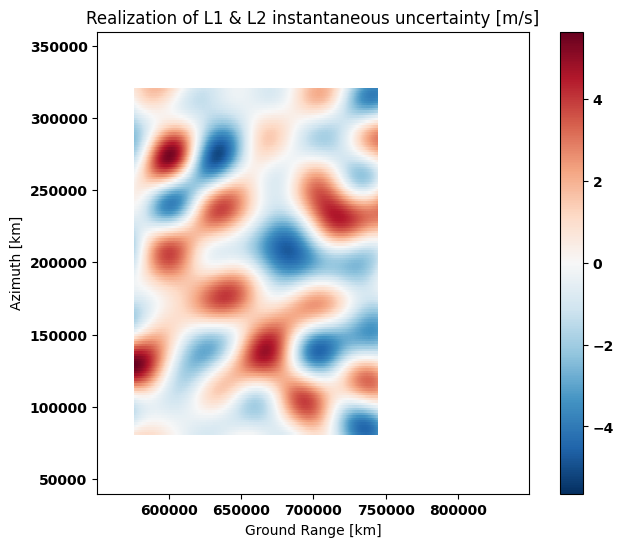

In [39]:
fig, axes = plt.subplots(ncols=1, nrows=1, sharex=True, sharey=True, figsize = (8, 6))

total_uncertainty = simulation['wave_dop_residual_velocity_noisy'].interp({"az":ds["az_slow_time"], "grg":ds["grg"]}) + ds['V_sigma_net_lpf']
total_uncertainty.plot()
print(func_rmse(total_uncertainty))

_ = axes.set_aspect('equal')
_ = axes.set_title("Realization of L1 & L2 instantaneous uncertainty [m/s]")
_ = axes.set_xlabel("Ground Range [km]")
_ = axes.set_ylabel("Azimuth [km]")